# 21_SVM

In [1]:
import pandas as pd
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.datasets import fetch_california_housing
from google.colab import drive
import os

# Google Drive Mount
drive.mount('/content/drive')

# Dataset을 저장할 Folder
data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


# Support Vector Machine

지금까지 여러 Classification Methods를 살펴보았다.

- Logistic Regression: Probability
- k-NN: Distance
- Naive Bayes: Probability Distribution
- Decision Tree: Rules
- Random Forest / Boosting: Multiple Trees

이번에는 Class 사이의 경계를 이용하여 Classification하는 방법을 살펴본다.

Support Vector Machine, SVM의 기본 아이디어는 다음과 같다.

> 두 Classes를 나누는 여러 경계 중에서 가장 넓은 Margin을 가지는 경계를 선택한다.

# Support Vector Machine

지금까지 여러 Classification Methods를 살펴보았다.

- Logistic Regression: Probability
- k-NN: Distance
- Naive Bayes: Probability Distribution
- Decision Tree: Rules
- Random Forest / Boosting: Multiple Trees

이번에는 Class 사이의 경계를 이용하여 Classification하는 방법을 살펴본다.

Support Vector Machine, SVM의 기본 아이디어는 다음과 같다.

> 두 Classes를 나누는 여러 경계 중에서 가장 넓은 Margin을 가지는 경계를 선택한다.

## Margin

Decision Boundary와 가장 가까운 Training Data 사이의 거리를 Margin이라고 생각할 수 있다.

SVM은 이 Margin이 최대가 되는 Boundary를 찾는다.

> Wider Margin → More Robust Decision Boundary

Boundary에 가장 가까운 Data Points는 최종 Boundary를 결정하는 데 특히 중요한 역할을 한다.

이러한 Data Points를 Support Vectors라고 한다.

## Support Vectors

모든 Training Data가 Decision Boundary를 결정하는 데 동일하게 중요한 것은 아니다.

Boundary와 멀리 떨어진 Data보다 Boundary에 가까운 Data가 더 중요한 역할을 한다.

이러한 Data를 Support Vectors라고 한다.

따라서 SVM이라는 이름은

> Support Vectors를 이용하여 Decision Boundary를 결정한다

는 의미에서 나온다.

## Linear SVM

먼저 Straight Line을 이용하여 두 Classes를 나누는 Linear SVM을 적용한다.

Linear SVM의 Decision Boundary는

$$
w_1x_1+w_2x_2+b=0
$$

형태의 Line이다.

먼저 Train Data와 Test Data를 나눈다.

In [16]:
import pandas as pd
import numpy as np

df = pd.read_csv(data_path+'two_classes.csv')
df.head()

,x1,x2,y
0,2.164064,-1.012114,0
1,1.947562,-1.913494,0
2,-0.860753,-1.089006,1
3,2.530348,0.040822,0
4,1.014954,2.798955,0


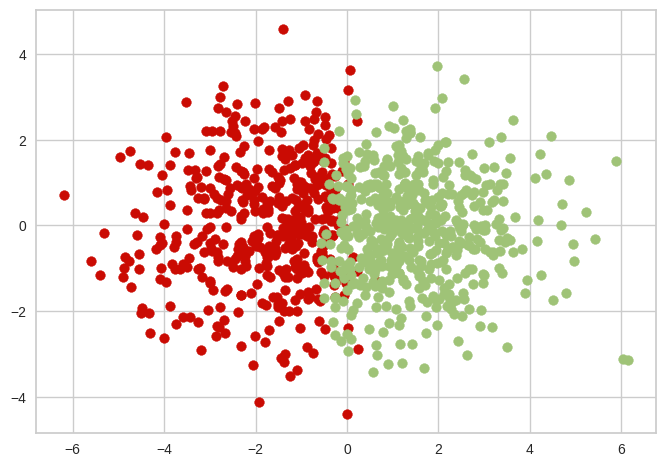

In [17]:
df_1 = df[df['y']==1]
df_0 = df[df['y']==0]

import matplotlib.pyplot as plt
plt.scatter(df_1['x1'], df_1['x2'], color = 'r')
plt.scatter(df_0['x1'], df_0['x2'], color = 'g')

In [18]:
from sklearn.svm import LinearSVC
X = df[['x1', 'x2']].to_numpy()
y = df['y']
print(X.shape)

(1000, 2)


In [19]:
svm_simple = LinearSVC(C = 1, loss='hinge')
svm_simple.fit(X, y)

LinearSVC(C=1, loss='hinge')

In [20]:
svm_simple.predict([[0.1, 0.6],[-4, 0]])

array([0, 1])

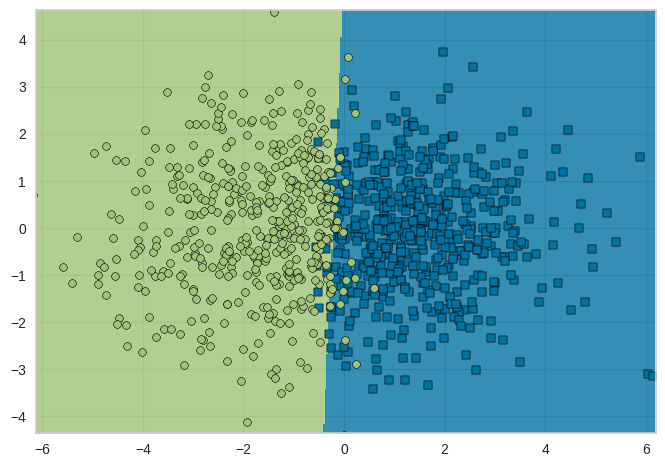

In [21]:
from yellowbrick.contrib.classifier import DecisionViz
viz = DecisionViz(svm_simple, title="Linear SVM")
viz.fit(X, y)
viz.draw(X, y)

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X = df[["x1", "x2"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = SVC(
    kernel="linear"
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Linear SVM Accuracy:",
    f"{accuracy:.3f}"
)

Linear SVM Accuracy: 0.960


In [25]:
for c in [0.01, 0.1, 1, 10, 100]:

    model = SVC(
        kernel="linear",
        C=c
    )

    model.fit(
        X_train,
        y_train
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        f"C={c}, "
        f"Accuracy={accuracy:.3f}"
    )

C=0.01, Accuracy=0.975
C=0.1, Accuracy=0.970
C=1, Accuracy=0.960
C=10, Accuracy=0.960
C=100, Accuracy=0.960


## Support Vectors Found by the Model

Training이 끝나면 SVM이 어떤 Samples를 Support Vectors로 사용했는지 확인할 수 있다.

Support Vectors는 Decision Boundary에 가까운 Training Samples이다.

In [26]:
print(
    "Number of Support Vectors:",
    model.n_support_
)

print()

print(
    "Support Vectors:"
)

print(
    model.support_vectors_[:10]
)

Number of Support Vectors: [45 46]

Support Vectors:
[[-0.02135122  0.9243922 ]
 [-0.16791722  0.63606892]
 [-0.54394299 -0.81550668]
 [-0.16117114 -1.07404679]
 [-0.34371011 -0.82029344]
 [-0.2533111  -2.5480857 ]
 [-0.25554305 -1.68411933]
 [-0.09824905  0.24299445]
 [-0.00393302  1.36670212]
 [-0.06959125 -0.21851422]]


## Parameter C

실제 Data에서는 모든 Samples를 완벽하게 분리하기 어려울 수 있다.

SVM에서는 Parameter `C`를 이용하여

- 넓은 Margin
- Training Error

사이의 Balance를 조절한다.

작은 `C`:

> 일부 Training Errors를 허용하면서 넓은 Margin을 선호

큰 `C`:

> Training Errors를 줄이는 것을 더 중요하게 고려

따라서 `C`는 SVM의 중요한 Hyperparameter이다.

In [ ]:
for c in [0.01, 0.1, 1, 10, 100]:

    model = SVC(
        kernel="linear",
        C=c
    )

    model.fit(
        X_train,
        y_train
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        f"C={c}, "
        f"Accuracy={accuracy:.3f}"
    )

## 비선형 SVM

## Kernel SVM

Kernel SVM은 원래 Feature Space에서 Straight Line으로 분리하기 어려운 Data를 더 높은 차원의 Feature Space에서 분리할 수 있도록 한다.

대표적인 Kernel 중 하나는 RBF Kernel이다.

Scikit-learn에서는 다음과 같이 사용할 수 있다.

`kernel="rbf"`

Kernel을 사용하면 Nonlinear Decision Boundary를 만들 수 있다.

In [32]:
import pandas as pd
import numpy as np

df = pd.read_csv(data_path+'twisted_data.csv')
df.head()

,x1,x2,y
0,-0.708553,-0.648847,0
1,0.326029,-0.551734,0
2,-3.105980,0.149616,0
3,-0.529565,-0.812004,0
4,2.837286,-0.176169,1


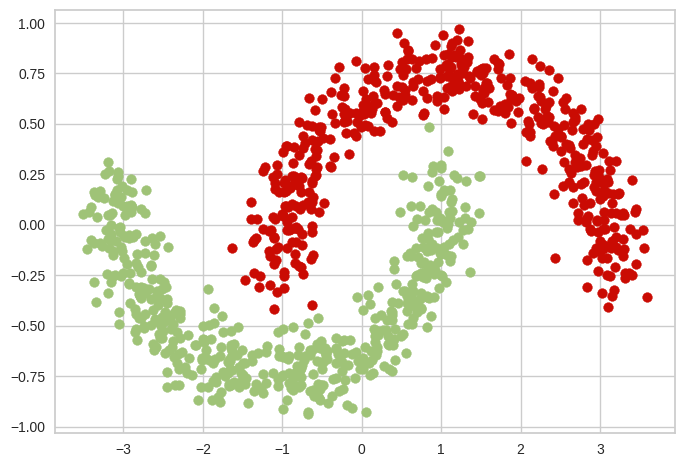

In [33]:
df_1 = df[df['y']==1]
df_0 = df[df['y']==0]

import matplotlib.pyplot as plt
plt.scatter(df_1['x1'], df_1['x2'], color = 'r')
plt.scatter(df_0['x1'], df_0['x2'], color = 'g')

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

X = df[["x1", "x2"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Linear SVM
linear_model = SVC(
    kernel="linear",
    C=1
)

linear_model.fit(
    X_train,
    y_train
)

y_pred = linear_model.predict(
    X_test
)

linear_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Linear SVM Accuracy:",
    f"{linear_accuracy:.3f}"
)

Linear SVM Accuracy: 0.890


## Visualize the Linear Decision Boundary

Linear SVM이 학습한 Decision Boundary를 Data와 함께 확인해 보자.

현재 Data는 Curve 형태이므로 Straight Line 하나로 두 Classes를 잘 분리할 수 있는지 관찰한다.

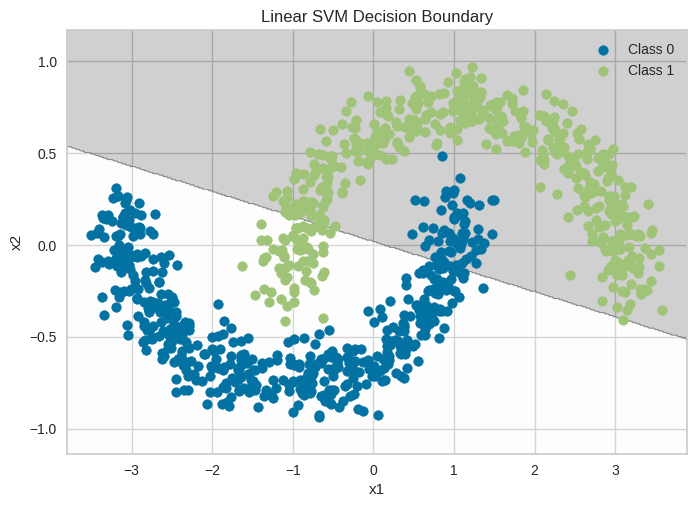

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Plot 영역
x1_min = df["x1"].min() - 0.3
x1_max = df["x1"].max() + 0.3
x2_min = df["x2"].min() - 0.2
x2_max = df["x2"].max() + 0.2

# Grid
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)

grid = pd.DataFrame({
    "x1": xx1.ravel(),
    "x2": xx2.ravel()
})

# Grid Prediction
Z = linear_model.predict(
    grid
).reshape(xx1.shape)

# Decision Region
plt.contourf(
    xx1,
    xx2,
    Z,
    alpha=0.2
)

# Actual Data
plt.scatter(
    df_0["x1"],
    df_0["x2"],
    label="Class 0"
)

plt.scatter(
    df_1["x1"],
    df_1["x2"],
    label="Class 1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Linear SVM Decision Boundary")
plt.legend()

plt.show()

## Is a Linear Boundary Enough?

Data의 분포를 보면 두 Classes 사이의 Boundary는 Straight Line 형태가 아니다.

따라서 Linear SVM만으로는 Data의 구조를 충분히 표현하기 어렵다.

이러한 경우 Nonlinear Decision Boundary를 만들 수 있는 Kernel SVM을 사용할 수 있다.

## RBF Kernel

RBF Kernel은 SVM이 Nonlinear Decision Boundary를 만들 수 있도록 한다.

Scikit-learn에서는

`kernel="rbf"`

를 사용한다.

같은 Training Data에 RBF SVM을 적용해 보자.

In [36]:
# RBF SVM
rbf_model = SVC(
    kernel="rbf",
    C=1
)

rbf_model.fit(
    X_train,
    y_train
)

y_pred = rbf_model.predict(
    X_test
)

rbf_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Linear SVM Accuracy:",
    f"{linear_accuracy:.3f}"
)

print(
    "RBF SVM Accuracy:",
    f"{rbf_accuracy:.3f}"
)

Linear SVM Accuracy: 0.890
RBF SVM Accuracy: 1.000


## Visualize the RBF Decision Boundary

RBF Kernel을 사용하여 만들어진 Nonlinear Decision Boundary를 확인해 보자.

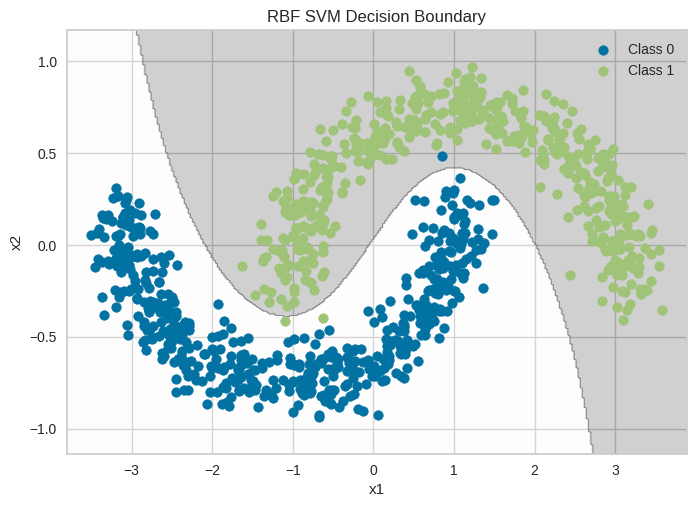

In [37]:
# Grid Prediction
Z = rbf_model.predict(
    grid
).reshape(xx1.shape)

# Decision Region
plt.contourf(
    xx1,
    xx2,
    Z,
    alpha=0.2
)

# Actual Data
plt.scatter(
    df_0["x1"],
    df_0["x2"],
    label="Class 0"
)

plt.scatter(
    df_1["x1"],
    df_1["x2"],
    label="Class 1"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("RBF SVM Decision Boundary")
plt.legend()

plt.show()

Linear SVM은 Straight Decision Boundary를 사용한다.

RBF SVM은 Data의 Nonlinear Pattern에 맞는 Curve 형태의 Decision Boundary를 만들 수 있다.

따라서 현재 Data에서는 Kernel을 사용하는 이유를 시각적으로 확인할 수 있다.

## Effect of C

`C`는 Training Error와 Margin 사이의 Balance를 조절한다.

작은 `C`:

- 일부 Classification Error를 허용한다.
- 보다 넓고 단순한 Margin을 선호한다.

큰 `C`:

- Training Error를 줄이는 것을 더 중요하게 생각한다.
- Data에 더 세밀하게 맞는 Boundary가 만들어질 수 있다.

여러 `C` 값을 비교해 보자.

In [39]:
for c in [0.1, 1, 10, 100]:

    model = SVC(
        kernel="rbf",
        C=c
    )

    model.fit(
        X_train,
        y_train
    )

    accuracy = model.score(
        X_test,
        y_test
    )

    print(
        f"C={c}, "
        f"Accuracy={accuracy:.3f}"
    )

C=0.1, Accuracy=0.980
C=1, Accuracy=1.000
C=10, Accuracy=1.000
C=100, Accuracy=1.000


## Homework - Problem 21

`svm_data2.csv`를 이용하여 SVM Classification을 수행한다.

다음 조건을 사용한다.

- `test_size=0.2`
- `random_state=42`
- `C=1`

다음 Kernels을 비교한다.

- `linear`
- `poly`
- `rbf`

다음 질문에 답하시오.

- 각 Kernel의 Test Accuracy를 소수점 셋째 자리까지 적으시오.
- 가장 높은 Test Accuracy를 보인 Kernel을 적으시오.

답만 제출하시오.